# Script to only lookup HPO terms for dominant diseases (not all diseases) that DnD genes are linked to

In [1]:
import obonet
import networkx as nx

# imports
import os
import sys
import numpy as np
import pandas as pd
from datetime import datetime
from itertools import permutations, combinations, product
import itertools
DATE = datetime.now().strftime("%Y-%m-%d")

import matplotlib.pyplot as plt
#import seaborn as sns
from matplotlib.ticker import FuncFormatter
import pickle
import math
import requests
import time
import urllib.request
from urllib.error import HTTPError

In [ ]:
# load gene names from exon file
exon_file="../../data/dnd_ensembl/dnd_ensembl_data.csv"
exon_df=pd.read_csv(exon_file)

In [2]:
# load exon file
exon_df = pd.read_csv('../../data/dnd_ensembl/dnd_ensembl_data.csv')
mdf.columns

Index(['hgnc_symbol', 'GENE ID (HGNC)', 'DISEASE LABEL', 'DISEASE ID (MONDO)',
       'MOI', 'CLASSIFICATION', 'HI Score', '%HI', 'pLI', 'LOEUF', 'total_plp',
       'missense_plp', 'nonsense_plp', 'ensg', 'chrom', 'obs_lof', 'exp_lof',
       'prior_mean', 'post_mean', 'post_lower_95', 'post_upper_95',
       'indel_targetable_pre_NMD_assessment', 'num_indel_vars',
       'crisproff_targetable', 'num_crisproff_vars', 'base_editable',
       'num_base_editable_vars', 'excision_targetable', 'num_excision_vars',
       'num_excision_pairs', 'HPO_term_list', 'Approved name',
       'indel_pam_targetable', 'crisproff_pam_targetable',
       'base_edit_pam_targetable', 'excision_pam_targetable',
       'hets_across_strats', 'prop_hets_across_strats', 'num_indel_hets',
       'indel_hets_prop', 'num_crisproff_hets', 'crisproff_hets_prop',
       'num_base_edit_hets', 'base_edit_hets_prop', 'num_excision_hets',
       'excision_hets_prop', 'hets_across_strats_prePAM',
       'prop_hets_across

In [4]:
exon_df=mdf.copy()

In [5]:
for gene in exon_df.hgnc_symbol.unique():
    print(gene)

AARS1
ABCB6
ABCC6
ABCC8
ABCC9
ACAN
ACD
ACO2
ACOX1
ACTA1
ACTA2
ACTB
ACTC1
ACTG1
ACTL6A
ACTN1
ACTN2
ACVR1
ADAR
ADCY5
AFG3L2
AGO2
AICDA
AKT3
ALB
ALDH18A1
ALG5
ALG8
ALG9
ALK
ALPK3
ALPL
ANK1
ANKRD26
ANO5
ANXA11
AP1G1
AP2M1
APP
ARF1
ARHGAP29
ASXL2
ATL1
ATL3
ATP11A
ATP13A3
ATP1A1
ATP1A2
ATP1A3
ATP2B2
ATXN2
BACH2
BCL11B
BEST1
BICRA
BRAF
BRD4
BRSK2
BSCL2
C19orf12
C1QTNF5
C3
C9orf72
CACNA1C
CACNA1D
CACNA1E
CACNA1S
CALM1
CALM2
CALM3
CAMK2A
CAPN3
CAPN5
CARD11
CASQ2
CASR
CAV1
CAV3
CBL
CCM2
CCND2
CD164
CD2AP
CD46
CDC42
CDH11
CDK4
CEACAM16
CEBPA
CEL
CEP85L
CFB
CFH
CFI
CHAMP1
CHCHD10
CHD3
CHD4
CHMP2B
CHN1
CHRNA4
CHRNB1
CHRNB2
CITED2
CLCN6
CLCN7
CNNM2
CNOT3
COCH
COL10A1
COL11A1
COL11A2
COL1A2
COL4A3
COL4A4
COL5A2
COL6A1
COL6A2
COL6A3
COMP
CPOX
CRX
CSDE1
CSNK2A1
CSNK2B
CSRP3
CTLA4
CTNND1
CTR9
CUX2
CXCR4
CYFIP2
DCC
DCTN1
DDR2
DES
DHX30
DIAPH1
DNAJB11
DNAJB6
DNAJC5
DNM1
DNM1L
DNM2
DPF2
DSC2
DSPP
EED
EEF1A2
EFEMP1
EGFR
EGR2
EIF2S3
ELANE
ELOVL4
ELP4
EMC1
EPCAM
EPHB4
ETS1
EZH2
F11
F12
F2
F5
FAM111B
FAR1
FBLN

## Input gene names into https://biomart.genenames.org/martform/#!/default/HGNC?datasets=hgnc_gene_mart_2026_03_20 to get OMIM ID mappings
Save to data/dnd_omim/dnd_omim_mapped.txt

In [6]:
# load OMIM mappings from HGNC biomart (oge = omim gene mappings)
ogm = pd.read_table('../../data/dnd_omim/dnd_omim_mapped.txt')
ogm

,HGNC ID,Status,Approved symbol,Approved name,OMIM ID,Orphanet ID
0,HGNC:20,Approved,AARS1,alanyl-tRNA synthetase 1,601065,232194.0
1,HGNC:47,Approved,ABCB6,ATP binding cassette subfamily B member 6 (LAN...,605452,291794.0
2,HGNC:57,Approved,ABCC6,ATP binding cassette subfamily C member 6,603234,117658.0
3,HGNC:59,Approved,ABCC8,ATP binding cassette subfamily C member 8,600509,117665.0
4,HGNC:60,Approved,ABCC9,ATP binding cassette subfamily C member 9,601439,117673.0
...,...,...,...,...,...,...
588,HGNC:14415,Approved,ELOVL4,ELOVL fatty acid elongase 4,605512,121522.0
589,HGNC:1171,Approved,ELP4,elongator acetyltransferase complex subunit 4,606985,NaN
590,HGNC:28957,Approved,EMC1,ER membrane protein complex subunit 1,616846,470272.0
591,HGNC:11529,Approved,EPCAM,epithelial cell adhesion molecule,185535,226018.0


In [8]:
# zip into a dictionary
gene2omim = dict(zip(ogm['Approved symbol'], ogm['OMIM ID']))
gene2omim

{'AARS1': 601065,
 'ABCB6': 605452,
 'ABCC6': 603234,
 'ABCC8': 600509,
 'ABCC9': 601439,
 'ACAN': 155760,
 'ACD': 609377,
 'ACO2': 100850,
 'ACOX1': 609751,
 'ACTA1': 102610,
 'ACTA2': 102620,
 'ACTB': 102630,
 'ACTC1': 102540,
 'ACTG1': 102560,
 'ACTL6A': 604958,
 'ACTN1': 102575,
 'ACTN2': 102573,
 'ACVR1': 102576,
 'ADAR': 146920,
 'ADCY5': 600293,
 'AFG3L2': 604581,
 'AGO2': 606229,
 'AICDA': 605257,
 'AKT3': 611223,
 'ALB': 103600,
 'ALDH18A1': 138250,
 'ALG5': 604565,
 'ALG8': 608103,
 'ALG9': 606941,
 'ALK': 105590,
 'ETS1': 164720,
 'EZH2': 601573,
 'F2': 176930,
 'F5': 612309,
 'F11': 264900,
 'F12': 610619,
 'FAM111B': 615584,
 'FAR1': 616107,
 'FBLN5': 604580,
 'FBXO38': 608533,
 'FGA': 134820,
 'FGB': 134830,
 'FGF8': 600483,
 'FGF9': 600921,
 'FGF12': 601513,
 'FGFR2': 176943,
 'FGFR3': 134934,
 'FGG': 134850,
 'FHOD3': 609691,
 'FLI1': 193067,
 'FLT4': 136352,
 'FN1': 135600,
 'FOXA2': 600288,
 'FOXE3': 601094,
 'FOXJ1': 602291,
 'FOXN1': 600838,
 'FTH1': 134770,
 'FUS':

In [9]:
# check that no values are strings
[x for x in list(gene2omim.values()) if isinstance(x,str)]

[]

## Workflow
Gene name --> gene OMIM ID --> linked disease OMIM IDs --> Filter for dominant conditions --> Map disease OMIM IDs to HPO terms --> get top level organ system HPO terms for all disease HPO terms

### NOTE: In order to query the OMIM API in the code below, you will need to request an API key from OMIM from this site: https://www.omim.org/api

In [ ]:
# set up some helper functions
api_key="" # update with your OMIM API key
def query_omim(omim_ids, api_key="", batch_size=20, sleep_s=0.3):
    """
    Queries OMIM in batches and returns a combined JSON dict.
    Raises HTTPError if any request fails.
    """
    if not omim_ids:
        return None
        
    omim_ids = [str(x) for x in omim_ids]
    # strip omim ids of any 'PS' prefixes
    cleaned=[
    v[2:] if v.startswith("PS") else v
    for v in omim_ids
    ]

    # response structure that we'll fill upon each batch
    combined_response = {
        "omim": {
            "entryList": []
        }
    }

    for i in range(0, len(cleaned), batch_size):
        batch = cleaned[i:i + batch_size]

        url = (
            "https://api.omim.org/api/entry?mimNumber=" +
            "%2C".join(batch) +
            "&include=clinicalSynopsis&include=geneMap"
            "&format=json&apiKey=" + api_key
        )

        response = requests.get(url, timeout=30)
        response.raise_for_status()

        json_data = response.json()

        entry_list = json_data.get("omim", {}).get("entryList", [])
        combined_response["omim"]["entryList"].extend(entry_list)

        time.sleep(sleep_s)

    return combined_response

# helper function to parse json data and determine if an OMIM ID is associated with dominance
def parse_json(json_data):
    final_dict={}
    for entry_wrapper in json_data.get("omim", {}).get("entryList", []):
        var_assoc_with_dominance=False
        entry = entry_wrapper.get("entry", {})
        mim_number = entry.get("mimNumber")
        #print('mim_number')

        pheno_map_inheritance_list=[]
        dom_disease_omims=[]

        pm_list = entry.get("phenotypeMapList")
        if pm_list is None:
            pm_list = entry.get("geneMap", {}).get("phenotypeMapList", [])
        #print(entry.get("phenotypeMapList", []))
        for list_item in pm_list:
            #print(list_item)
            pheno_inheritance=list_item.get("phenotypeMap",{}).get("phenotypeInheritance", "")
            pheno_mim_number=str(list_item.get("phenotypeMap",{}).get("phenotypeMimNumber",""))
            if (pheno_inheritance is not None) and (pheno_inheritance!="None"):
                if "Autosomal dominant" in pheno_inheritance:
                    if pheno_mim_number.startswith("PS"):
                        pheno_mim_number = pheno_mim_number[2:]
                    dom_disease_omims.append(pheno_mim_number)
        final_dict[mim_number] = dom_disease_omims
    return final_dict


In [12]:
# Run the omim query on gene OMIM ids
json_data = query_omim(list(gene2omim.values()))

In [13]:
# parse the resulting data
mim_dom_map = parse_json(json_data)
mim_dom_map

{601065: ['619661', '613287'],
 102560: ['614583', '604717'],
 605452: ['615402', '614497', '609153'],
 102630: ['243310', '607371', '620475'],
 609377: ['616553', '616553'],
 146920: ['127400'],
 603234: ['177850'],
 102573: ['612158', '612158', '618654', '618655'],
 600293: ['606703'],
 102540: ['612794', '613424', '612098', '613424'],
 102575: ['615193'],
 102576: ['135100'],
 155760: ['608361', '165800'],
 100850: ['616289'],
 102610: ['616852', '161800', '620278'],
 600509: ['125853', '618857', '610374', '256450', '240800', '621196'],
 601439: ['614050', '608569', '239850'],
 604958: [],
 102620: ['611788', '613834'],
 609751: ['618960'],
 605257: [],
 176930: ['614390', '188050'],
 264900: [],
 616107: ['619338'],
 138250: ['616603', '601162'],
 615584: ['615704'],
 604581: ['618977', '610246'],
 601573: ['277590'],
 604580: ['614434', '619764', '608895'],
 608103: ['617874'],
 103600: ['615999', '615999'],
 164720: [],
 610619: ['610618'],
 606941: [],
 105590: [],
 606229: ['61

In [14]:
# check that we still have the right amount of genes
len(mim_dom_map.keys())

593

In [16]:
gene2omim

{'AARS1': 601065,
 'ABCB6': 605452,
 'ABCC6': 603234,
 'ABCC8': 600509,
 'ABCC9': 601439,
 'ACAN': 155760,
 'ACD': 609377,
 'ACO2': 100850,
 'ACOX1': 609751,
 'ACTA1': 102610,
 'ACTA2': 102620,
 'ACTB': 102630,
 'ACTC1': 102540,
 'ACTG1': 102560,
 'ACTL6A': 604958,
 'ACTN1': 102575,
 'ACTN2': 102573,
 'ACVR1': 102576,
 'ADAR': 146920,
 'ADCY5': 600293,
 'AFG3L2': 604581,
 'AGO2': 606229,
 'AICDA': 605257,
 'AKT3': 611223,
 'ALB': 103600,
 'ALDH18A1': 138250,
 'ALG5': 604565,
 'ALG8': 608103,
 'ALG9': 606941,
 'ALK': 105590,
 'ETS1': 164720,
 'EZH2': 601573,
 'F2': 176930,
 'F5': 612309,
 'F11': 264900,
 'F12': 610619,
 'FAM111B': 615584,
 'FAR1': 616107,
 'FBLN5': 604580,
 'FBXO38': 608533,
 'FGA': 134820,
 'FGB': 134830,
 'FGF8': 600483,
 'FGF9': 600921,
 'FGF12': 601513,
 'FGFR2': 176943,
 'FGFR3': 134934,
 'FGG': 134850,
 'FHOD3': 609691,
 'FLI1': 193067,
 'FLT4': 136352,
 'FN1': 135600,
 'FOXA2': 600288,
 'FOXE3': 601094,
 'FOXJ1': 602291,
 'FOXN1': 600838,
 'FTH1': 134770,
 'FUS':

In [17]:
# Map dominant omim IDs back to gene name
gene_dom_omim = {
    gene: mim_dom_map.get(mim_id, [])  # default to empty list if no entry
    for gene, mim_id in gene2omim.items()
}
gene_dom_omim

{'AARS1': ['619661', '613287'],
 'ABCB6': ['615402', '614497', '609153'],
 'ABCC6': ['177850'],
 'ABCC8': ['125853', '618857', '610374', '256450', '240800', '621196'],
 'ABCC9': ['614050', '608569', '239850'],
 'ACAN': ['608361', '165800'],
 'ACD': ['616553', '616553'],
 'ACO2': ['616289'],
 'ACOX1': ['618960'],
 'ACTA1': ['616852', '161800', '620278'],
 'ACTA2': ['611788', '613834'],
 'ACTB': ['243310', '607371', '620475'],
 'ACTC1': ['612794', '613424', '612098', '613424'],
 'ACTG1': ['614583', '604717'],
 'ACTL6A': [],
 'ACTN1': ['615193'],
 'ACTN2': ['612158', '612158', '618654', '618655'],
 'ACVR1': ['135100'],
 'ADAR': ['127400'],
 'ADCY5': ['606703'],
 'AFG3L2': ['618977', '610246'],
 'AGO2': ['619149'],
 'AICDA': [],
 'AKT3': ['615937'],
 'ALB': ['615999', '615999'],
 'ALDH18A1': ['616603', '601162'],
 'ALG5': ['620056'],
 'ALG8': ['617874'],
 'ALG9': [],
 'ALK': [],
 'ETS1': [],
 'EZH2': ['277590'],
 'F2': ['614390', '188050'],
 'F5': ['614389', '188055', '188055'],
 'F11': []

In [18]:
## Now map dominant OMIM ids to HPO terms
# we can do this using the phenotype.hpoa file, which provides inter-ontology mappings
pheno_map_fp = '../../data/hpo/phenotype.hpoa'
hpo_df = pd.read_csv(pheno_map_fp, sep='\t', comment='#')

/var/folders/d8/m8_nz4tx72l143cvq_1skt6h0000gn/T/ipykernel_97386/3268685840.py:3: DtypeWarning: Columns (2,6,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  hpo_df = pd.read_csv(pheno_map_fp, sep='\t', comment='#')


,database_id,disease_name,qualifier,hpo_id,reference,evidence,onset,frequency,sex,modifier,aspect,biocuration
0,OMIM:619340,Developmental and epileptic encephalopathy 96,NaN,HP:0011097,PMID:31675180,PCS,NaN,1/2,NaN,NaN,P,HPO:probinson[2021-06-21]
1,OMIM:619340,Developmental and epileptic encephalopathy 96,NaN,HP:0002187,PMID:31675180,PCS,NaN,1/1,NaN,NaN,P,HPO:probinson[2021-06-21]
2,OMIM:619340,Developmental and epileptic encephalopathy 96,NaN,HP:0001518,PMID:31675180,PCS,NaN,1/2,NaN,NaN,P,HPO:probinson[2021-06-21]
3,OMIM:619340,Developmental and epileptic encephalopathy 96,NaN,HP:0032792,PMID:31675180,PCS,NaN,1/2,NaN,NaN,P,HPO:probinson[2021-06-21]
4,OMIM:619340,Developmental and epileptic encephalopathy 96,NaN,HP:0011451,PMID:31675180,PCS,NaN,1/2,NaN,NaN,P,HPO:probinson[2021-06-21]
...,...,...,...,...,...,...,...,...,...,...,...,...
276012,ORPHA:1777,Temtamy syndrome,NaN,HP:0000324,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2025-11-24]
276013,ORPHA:1777,Temtamy syndrome,NaN,HP:0000506,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2025-11-24]
276014,ORPHA:1777,Temtamy syndrome,NaN,HP:0000568,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2025-11-24]
276015,ORPHA:1777,Temtamy syndrome,NaN,HP:0004209,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2025-11-24]


In [19]:
# list of dominant OMIM IDs with 'OMIM' prefix attached
all_dom_omim_ids = set()
for val in list(gene_dom_omim.values()):
    all_dom_omim_ids.update(val)
all_dom_omim_ids={'OMIM:'+x for x in all_dom_omim_ids}
all_dom_omim_ids

{'OMIM:100800',
 'OMIM:101200',
 'OMIM:101400',
 'OMIM:101600',
 'OMIM:102500',
 'OMIM:103285',
 'OMIM:104200',
 'OMIM:104290',
 'OMIM:104300',
 'OMIM:105200',
 'OMIM:105210',
 'OMIM:105400',
 'OMIM:105500',
 'OMIM:105550',
 'OMIM:106100',
 'OMIM:106260',
 'OMIM:108120',
 'OMIM:112250',
 'OMIM:113500',
 'OMIM:115000',
 'OMIM:115150',
 'OMIM:115195',
 'OMIM:115196',
 'OMIM:115210',
 'OMIM:115430',
 'OMIM:116400',
 'OMIM:117000',
 'OMIM:117360',
 'OMIM:118200',
 'OMIM:118700',
 'OMIM:120790',
 'OMIM:120970',
 'OMIM:121201',
 'OMIM:121300',
 'OMIM:123150',
 'OMIM:123320',
 'OMIM:123500',
 'OMIM:123790',
 'OMIM:124900',
 'OMIM:125250',
 'OMIM:125420',
 'OMIM:125490',
 'OMIM:125500',
 'OMIM:125852',
 'OMIM:125853',
 'OMIM:126600',
 'OMIM:126700',
 'OMIM:127400',
 'OMIM:127550',
 'OMIM:127750',
 'OMIM:128101',
 'OMIM:128235',
 'OMIM:129400',
 'OMIM:129500',
 'OMIM:130010',
 'OMIM:132400',
 'OMIM:132900',
 'OMIM:133190',
 'OMIM:133200',
 'OMIM:134610',
 'OMIM:135100',
 'OMIM:135300',
 'OMIM:1

In [20]:
# filter annotations to only your OMIM IDs
filtered = hpo_df[hpo_df['database_id'].isin(all_dom_omim_ids)]

# create mapping: OMIM disease ID-> list of HPO IDs
omim2hpo = filtered.groupby('database_id')['hpo_id'].apply(list).to_dict()

In [22]:
# view that map here
omim2hpo

{'OMIM:100800': ['HP:0003015',
  'HP:0008947',
  'HP:0005733',
  'HP:0003577',
  'HP:0002980',
  'HP:0001377',
  'HP:0001355',
  'HP:0002089',
  'HP:0008905',
  'HP:0004565',
  'HP:0001156',
  'HP:0002761',
  'HP:0005257',
  'HP:0003375',
  'HP:0002781',
  'HP:0003097',
  'HP:0003031',
  'HP:0003093',
  'HP:0001270',
  'HP:0004060',
  'HP:0100864',
  'HP:0008450',
  'HP:0002938',
  'HP:0002979',
  'HP:0000238',
  'HP:0001522',
  'HP:0008414',
  'HP:0000256',
  'HP:0000773',
  'HP:0001788',
  'HP:0002512',
  'HP:0002677',
  'HP:0001561',
  'HP:0000452',
  'HP:0002970',
  'HP:0011968',
  'HP:0002098',
  'HP:0000272',
  'HP:6000920',
  'HP:0011800',
  'HP:0005280',
  'HP:0000403',
  'HP:0000405',
  'HP:0002007',
  'HP:0008921',
  'HP:0002986',
  'HP:0000006'],
 'OMIM:101200': ['HP:0001331',
  'HP:0002663',
  'HP:0001177',
  'HP:0000244',
  'HP:0000684',
  'HP:0000365',
  'HP:0000486',
  'HP:0004487',
  'HP:0004443',
  'HP:0002021',
  'HP:0004442',
  'HP:0004440',
  'HP:0010055',
  'HP:001

In [23]:
# now, for one of the final mappings, get gene name --> HPO terms
gene2hpo = {
    gene: [hpo for omim_id in ["OMIM:" + x for x in omim_ids] for hpo in omim2hpo.get(omim_id, [])]
    for gene, omim_ids in gene_dom_omim.items()
}

In [24]:
gene2hpo # view dictionary

{'AARS1': ['HP:0001332',
  'HP:0001288',
  'HP:0002352',
  'HP:0002063',
  'HP:0003581',
  'HP:0010871',
  'HP:0030903',
  'HP:0031358',
  'HP:0012377',
  'HP:0000726',
  'HP:0012196',
  'HP:0000751',
  'HP:0001268',
  'HP:0000006',
  'HP:0003202',
  'HP:0003477',
  'HP:0001265',
  'HP:0003621',
  'HP:0003596',
  'HP:0003431',
  'HP:0001761',
  'HP:0002460',
  'HP:0001284',
  'HP:0000407',
  'HP:0007340',
  'HP:0011462',
  'HP:0009027',
  'HP:0002936',
  'HP:0003438',
  'HP:0000006',
  'HP:0001765',
  'HP:0008944'],
 'ABCB6': ['HP:0001034',
  'HP:0020073',
  'HP:0011463',
  'HP:0000006',
  'HP:0003577',
  'HP:0000568',
  'HP:0000612',
  'HP:0000006',
  'HP:0031613',
  'HP:0002378',
  'HP:0003324',
  'HP:0002153',
  'HP:0003394',
  'HP:0001878',
  'HP:0003768',
  'HP:0000006'],
 'ABCC6': ['HP:0001342',
  'HP:0001102',
  'HP:0002650',
  'HP:0000573',
  'HP:0025533',
  'HP:0001681',
  'HP:0000592',
  'HP:0005462',
  'HP:0005297',
  'HP:0012457',
  'HP:0002808',
  'HP:0000608',
  'HP:00007

## Now we'll map these HPO terms to their top-level terms

In [25]:
hpo_file='../../data/hpo/hp.obo'
# load HP ontology
graph = obonet.read_obo(hpo_file)

def get_top_level_categories(hpo_id):
    """Return top-level HPO categories (direct children of HP:0000118)
    that are ancestors of the given HPO term."""
    if hpo_id not in graph:
        return []
    ancestors = nx.ancestors(graph.reverse(), hpo_id)
    # keep only ancestors that are direct children of ROOT_ID
    matches = [tid for tid in top_level_ids if tid in ancestors]
    return [(tid, top_level_terms[tid]) for tid in matches]

# we want to group HPO terms linked to each gene into larger organ system categories
# identify those broader organ system categories of interest here
ROOT_ID = "HP:0000118"  # Highest order term that we'll use: Phenotypic abnormality
top_level_ids = list(graph.predecessors(ROOT_ID))
top_level_terms = {
    t_id: graph.nodes[t_id]['name'] for t_id in top_level_ids
}

In [26]:
top_level_terms # view top-level organ system terms

{'HP:0000119': 'Abnormality of the genitourinary system',
 'HP:0000152': 'Abnormality of head or neck',
 'HP:0000478': 'Abnormality of the eye',
 'HP:0000598': 'Abnormality of the ear',
 'HP:0000707': 'Abnormality of the nervous system',
 'HP:0000769': 'Abnormality of the breast',
 'HP:0000818': 'Abnormality of the endocrine system',
 'HP:0001197': 'Abnormality of prenatal development or birth',
 'HP:0001507': 'Growth abnormality',
 'HP:0001574': 'Abnormality of the integument',
 'HP:0001608': 'Abnormality of the voice',
 'HP:0001626': 'Abnormality of the cardiovascular system',
 'HP:0001871': 'Abnormality of blood and blood-forming tissues',
 'HP:0001939': 'Abnormality of metabolism/homeostasis',
 'HP:0002086': 'Abnormality of the respiratory system',
 'HP:0002664': 'Neoplasm',
 'HP:0002715': 'Abnormality of the immune system',
 'HP:0025031': 'Abnormality of the digestive system',
 'HP:0025142': 'Constitutional symptom',
 'HP:0025354': 'Abnormal cellular phenotype',
 'HP:0033127': 'Ab

## Mapping each gene's HPO terms to an organ system

In [27]:
# Flatten all unique HPO terms so you only have to map once
all_hpo_terms = set(term for terms in gene2hpo.values() for term in terms)

# Precompute top-level terms for each HPO term
hpo2top = {term: get_top_level_categories(term) for term in all_hpo_terms}

KeyboardInterrupt: 

In [ ]:
hpo2top # view overall mappings (not yet separated by gene)

In [ ]:
get_top_level_categories('HP:0032132') # look at an example term's organ systems - HP:0032132 is "Decreased circulating IgG"

In [118]:
# Map each gene to top-level categories
hpo2top_labels = {
    k: {label for _, label in v}
    for k, v in hpo2top.items()
}
gene2_top_level = {
    gene: set().union(*(hpo2top_labels.get(t, set()) for t in terms))
    for gene, terms in gene2hpo.items()
}

In [119]:
gene2_top_level # view final mapped terms

{'AARS1': {'Abnormality of limbs',
  'Abnormality of the ear',
  'Abnormality of the eye',
  'Abnormality of the musculoskeletal system',
  'Abnormality of the nervous system',
  'Abnormality of the respiratory system'},
 'ABCB6': {'Abnormality of blood and blood-forming tissues',
  'Abnormality of metabolism/homeostasis',
  'Abnormality of the eye',
  'Abnormality of the integument',
  'Abnormality of the musculoskeletal system',
  'Abnormality of the nervous system'},
 'ABCC6': {'Abnormality of blood and blood-forming tissues',
  'Abnormality of head or neck',
  'Abnormality of metabolism/homeostasis',
  'Abnormality of the cardiovascular system',
  'Abnormality of the digestive system',
  'Abnormality of the eye',
  'Abnormality of the integument',
  'Abnormality of the musculoskeletal system',
  'Abnormality of the nervous system'},
 'ABCC8': {'Abnormality of blood and blood-forming tissues',
  'Abnormality of metabolism/homeostasis',
  'Abnormality of the cardiovascular system',
 

In [3]:
# save top level HPO terms
with open('../../data/hpo/dnd2organ_system.pkl', 'wb') as fp:
    pickle.dump(gene2_top_level, fp)

NameError: name 'gene2_top_level' is not defined

In [6]:
with open('../../data/hpo/dnd2organ_system.pkl', 'rb') as fp:
    gene2_top_level = pickle.load(fp)

In [7]:
# let's also note the major organ systems of the genes not found in the mapping
counter=0
missing_genes=[]
for gene, organ_set in gene2_top_level.items():
    if len(organ_set)==0:
        print(gene)
        missing_genes.append(gene)
        counter+=1
print(counter)

0


In [154]:
missing = (gd[gd['GENE SYMBOL'].isin(missing_genes[0:50])][['GENE SYMBOL','DISEASE LABEL']]).reset_index(drop=True)
missing.sort_values(by=['GENE SYMBOL'], inplace=True)
missing

,GENE SYMBOL,DISEASE LABEL
0,ACTL6A,ACTL6A-related BAFopathy
29,AICDA,hyper-IgM syndrome type 2
1,ALG9,ALG9-associated autosomal dominant polycystic ...
28,ALK,"neuroblastoma, susceptibility to, 3"
32,ALPK3,hypertrophic cardiomyopathy
37,ARHGAP29,orofacial cleft
2,ATP13A3,pulmonary arterial hypertension
3,BRSK2,complex neurodevelopmental disorder
4,CASQ2,catecholaminergic polymorphic ventricular tach...
30,CD2AP,inherited focal segmental glomerulosclerosis


In [221]:
# print the ones that are too long
print(missing.loc[1,'GENE SYMBOL'], missing.loc[1,'DISEASE LABEL'])
print(missing.loc[4,'GENE SYMBOL'], missing.loc[4,'DISEASE LABEL'])
print(missing.loc[7,'GENE SYMBOL'], missing.loc[7,'DISEASE LABEL'])
print(missing.loc[18,'GENE SYMBOL'], missing.loc[18,'DISEASE LABEL'])
print(missing.loc[22,'GENE SYMBOL'], missing.loc[22,'DISEASE LABEL'])
print(missing.loc[27,'GENE SYMBOL'], missing.loc[27,'DISEASE LABEL'])
print(missing.loc[48,'GENE SYMBOL'], missing.loc[48,'DISEASE LABEL'])

ALG9 ALG9-associated autosomal dominant polycystic kidney disease
CASQ2 catecholaminergic polymorphic ventricular tachycardia
EMC1 complex neurodevelopmental disorder with motor features
MYH10 complex neurodevelopmental disorder with or without congenital anomalies
PIK3CA overgrowth syndrome and/or cerebral malformations due to abnormalities in MTOR pathway genes
TOP2B B-cell immunodeficiency, distal limb anomalies, and urogenital malformations
FOXA2 combined pituitary hormone deficiencies, genetic form


In [235]:
set1 = set([x for x in hpo_df.disease_name
 if isinstance(x, str) and 'BAFopathy'.lower() in x.lower()])

set1

set()

In [257]:
missing_genes_filled=pd.read_csv('../../data/hpo/missing_genes_terms.csv')
missing_genes_filled

,gene_missing_hpo,disease_term_in_hpo_df,manually_selected_terms_if_missing,Unnamed: 3
0,ACTL6A,Neurodevelopmental disorder with or without ea...,NaN,NaN
1,AICDA,"Immunodeficiency with hyper-igm, type 2",NaN,NaN
2,ALG9,Autosomal dominant polycystic kidney disease,NaN,Notes
3,ALK,"Neuroblastoma, susceptibility to",NaN,NaN
4,ALPK3,NaN,"['Abnormality of the cardiovascular system', '...",NaN
5,ARHGAP29,Orofacial cleft 1,NaN,NaN
6,ATP13A3,Idiopathic/heritable pulmonary arterial hypert...,NaN,NaN
7,BRSK2,Neurodevelopmental disorder with or without ea...,NaN,NaN
8,CASQ2,Catecholaminergic polymorphic ventricular tach...,NaN,NaN
9,CD2AP,Focal segmental glomerulosclerosis 1,NaN,NaN


In [258]:
from ast import literal_eval
disease2hpo = (
    hpo_df
    .groupby('disease_name')['hpo_id']
    .apply(set)
    .to_dict()
)
hpo2top_labels = {
    k: {label for _, label in v}
    for k, v in hpo2top.items()
}
for idx,row in missing_genes_filled.iterrows():
    gene=row.gene_missing_hpo
    if isinstance(row.disease_term_in_hpo_df, str):
        cur_hpo_terms = disease2hpo.get(row.disease_term_in_hpo_df, set())
        
        combined = set()
        for term in cur_hpo_terms:
            combined.update(hpo2top_labels.get(term, ()))

        gene2_top_level[gene] = combined
        
    else:
        gene2_top_level[gene] = set(
            literal_eval(row.manually_selected_terms_if_missing)
        )

In [261]:
print(len(set(gene2_top_level.keys())))
counter=0
for key, val in gene2_top_level.items():
    if len(val)==0:
        counter+=1
print('Num genes without HPO terms: ', counter)

593
Num genes without HPO terms:  0


In [262]:
# save the fully filled version top level HPO terms
with open('../../data/hpo/dnd2organ_system.pkl', 'wb') as fp:
    pickle.dump(gene2_top_level, fp)

## Now, let's tally these and plot them

In [12]:
# we'll use a horizontal bar plot to show the frequency of annotations
term_df_g1 = pd.DataFrame({
    'term': list(top_level_terms.values()),
    'num_genes_w_term_g1':0
})

for gene, cur_gene_terms in gene2_top_level.items():
    for term in cur_gene_terms:
        # filter to the row of the data frame with the current term's name
        rows_with_term = term_df_g1[term_df_g1['term'] == term]
        # get index of this row
        row_index = list(rows_with_term.index)[0]
        # increment its value by 1
        cur_val = term_df_g1.loc[row_index, 'num_genes_w_term_g1']
        new_val = cur_val+1
        term_df_g1.loc[row_index, 'num_genes_w_term_g1'] = new_val

In [13]:
term_df_g1.sort_values(by=['num_genes_w_term_g1'], inplace=True, ignore_index=True)
term_df_g1

,term,num_genes_w_term_g1
0,Abnormality of the thoracic cavity,2
1,Abnormality of the breast,24
2,Abnormality of the voice,25
3,Abnormal cellular phenotype,46
4,Neoplasm,59
5,Abnormality of prenatal development or birth,60
6,Abnormality of the endocrine system,71
7,Constitutional symptom,89
8,Abnormality of blood and blood-forming tissues,133
9,Growth abnormality,155


In [14]:
# let's do the same for genes that are in group two (s_het filter)
term_df_g2 = pd.DataFrame({
    'term': list(top_level_terms.values()),
    'num_genes_w_term_g2':0
})

g2_genes = list(mdf[mdf['post_mean']<0.1]['hgnc_symbol'].unique())
print(len(g2_genes))

for gene, cur_gene_terms in gene2_top_level.items():
    if gene in g2_genes:
        for term in cur_gene_terms:
            # filter to the row of the data frame with the current term's name
            rows_with_term = term_df_g2[term_df_g2['term'] == term]
            # get index of this row
            row_index = list(rows_with_term.index)[0]
            # increment its value by 1
            cur_val = term_df_g2.loc[row_index, 'num_genes_w_term_g2']
            new_val = cur_val+1
            term_df_g2.loc[row_index, 'num_genes_w_term_g2'] = new_val

363


In [15]:
term_df_g2.sort_values(by=['num_genes_w_term_g2'], inplace=True, ignore_index=True)
term_df_g2

,term,num_genes_w_term_g2
0,Abnormality of the thoracic cavity,1
1,Abnormality of the breast,6
2,Abnormality of the voice,13
3,Abnormal cellular phenotype,25
4,Abnormality of prenatal development or birth,26
5,Neoplasm,38
6,Abnormality of the endocrine system,40
7,Constitutional symptom,66
8,Growth abnormality,75
9,Abnormality of the immune system,86


In [16]:
# merge
term_df=term_df_g1.merge(term_df_g2, on='term', how='left')
term_df

,term,num_genes_w_term_g1,num_genes_w_term_g2
0,Abnormality of the thoracic cavity,2,1
1,Abnormality of the breast,24,6
2,Abnormality of the voice,25,13
3,Abnormal cellular phenotype,46,25
4,Neoplasm,59,38
5,Abnormality of prenatal development or birth,60,26
6,Abnormality of the endocrine system,71,40
7,Constitutional symptom,89,66
8,Abnormality of blood and blood-forming tissues,133,88
9,Growth abnormality,155,75


In [17]:
term_df['g1_percent']=(term_df['num_genes_w_term_g1']/593)*100
term_df['g2_percent']=(term_df['num_genes_w_term_g2']/363)*100
term_df.to_csv('')

,term,num_genes_w_term_g1,num_genes_w_term_g2,g1_percent,g2_percent
0,Abnormality of the thoracic cavity,2,1,0.337268,0.275482
1,Abnormality of the breast,24,6,4.047218,1.652893
2,Abnormality of the voice,25,13,4.215852,3.581267
3,Abnormal cellular phenotype,46,25,7.757167,6.887052
4,Neoplasm,59,38,9.949410,10.468320
5,Abnormality of prenatal development or birth,60,26,10.118044,7.162534
6,Abnormality of the endocrine system,71,40,11.973019,11.019284
7,Constitutional symptom,89,66,15.008432,18.181818
8,Abnormality of blood and blood-forming tissues,133,88,22.428331,24.242424
9,Growth abnormality,155,75,26.138280,20.661157


In [298]:
# increase dpi of fig
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

593
363


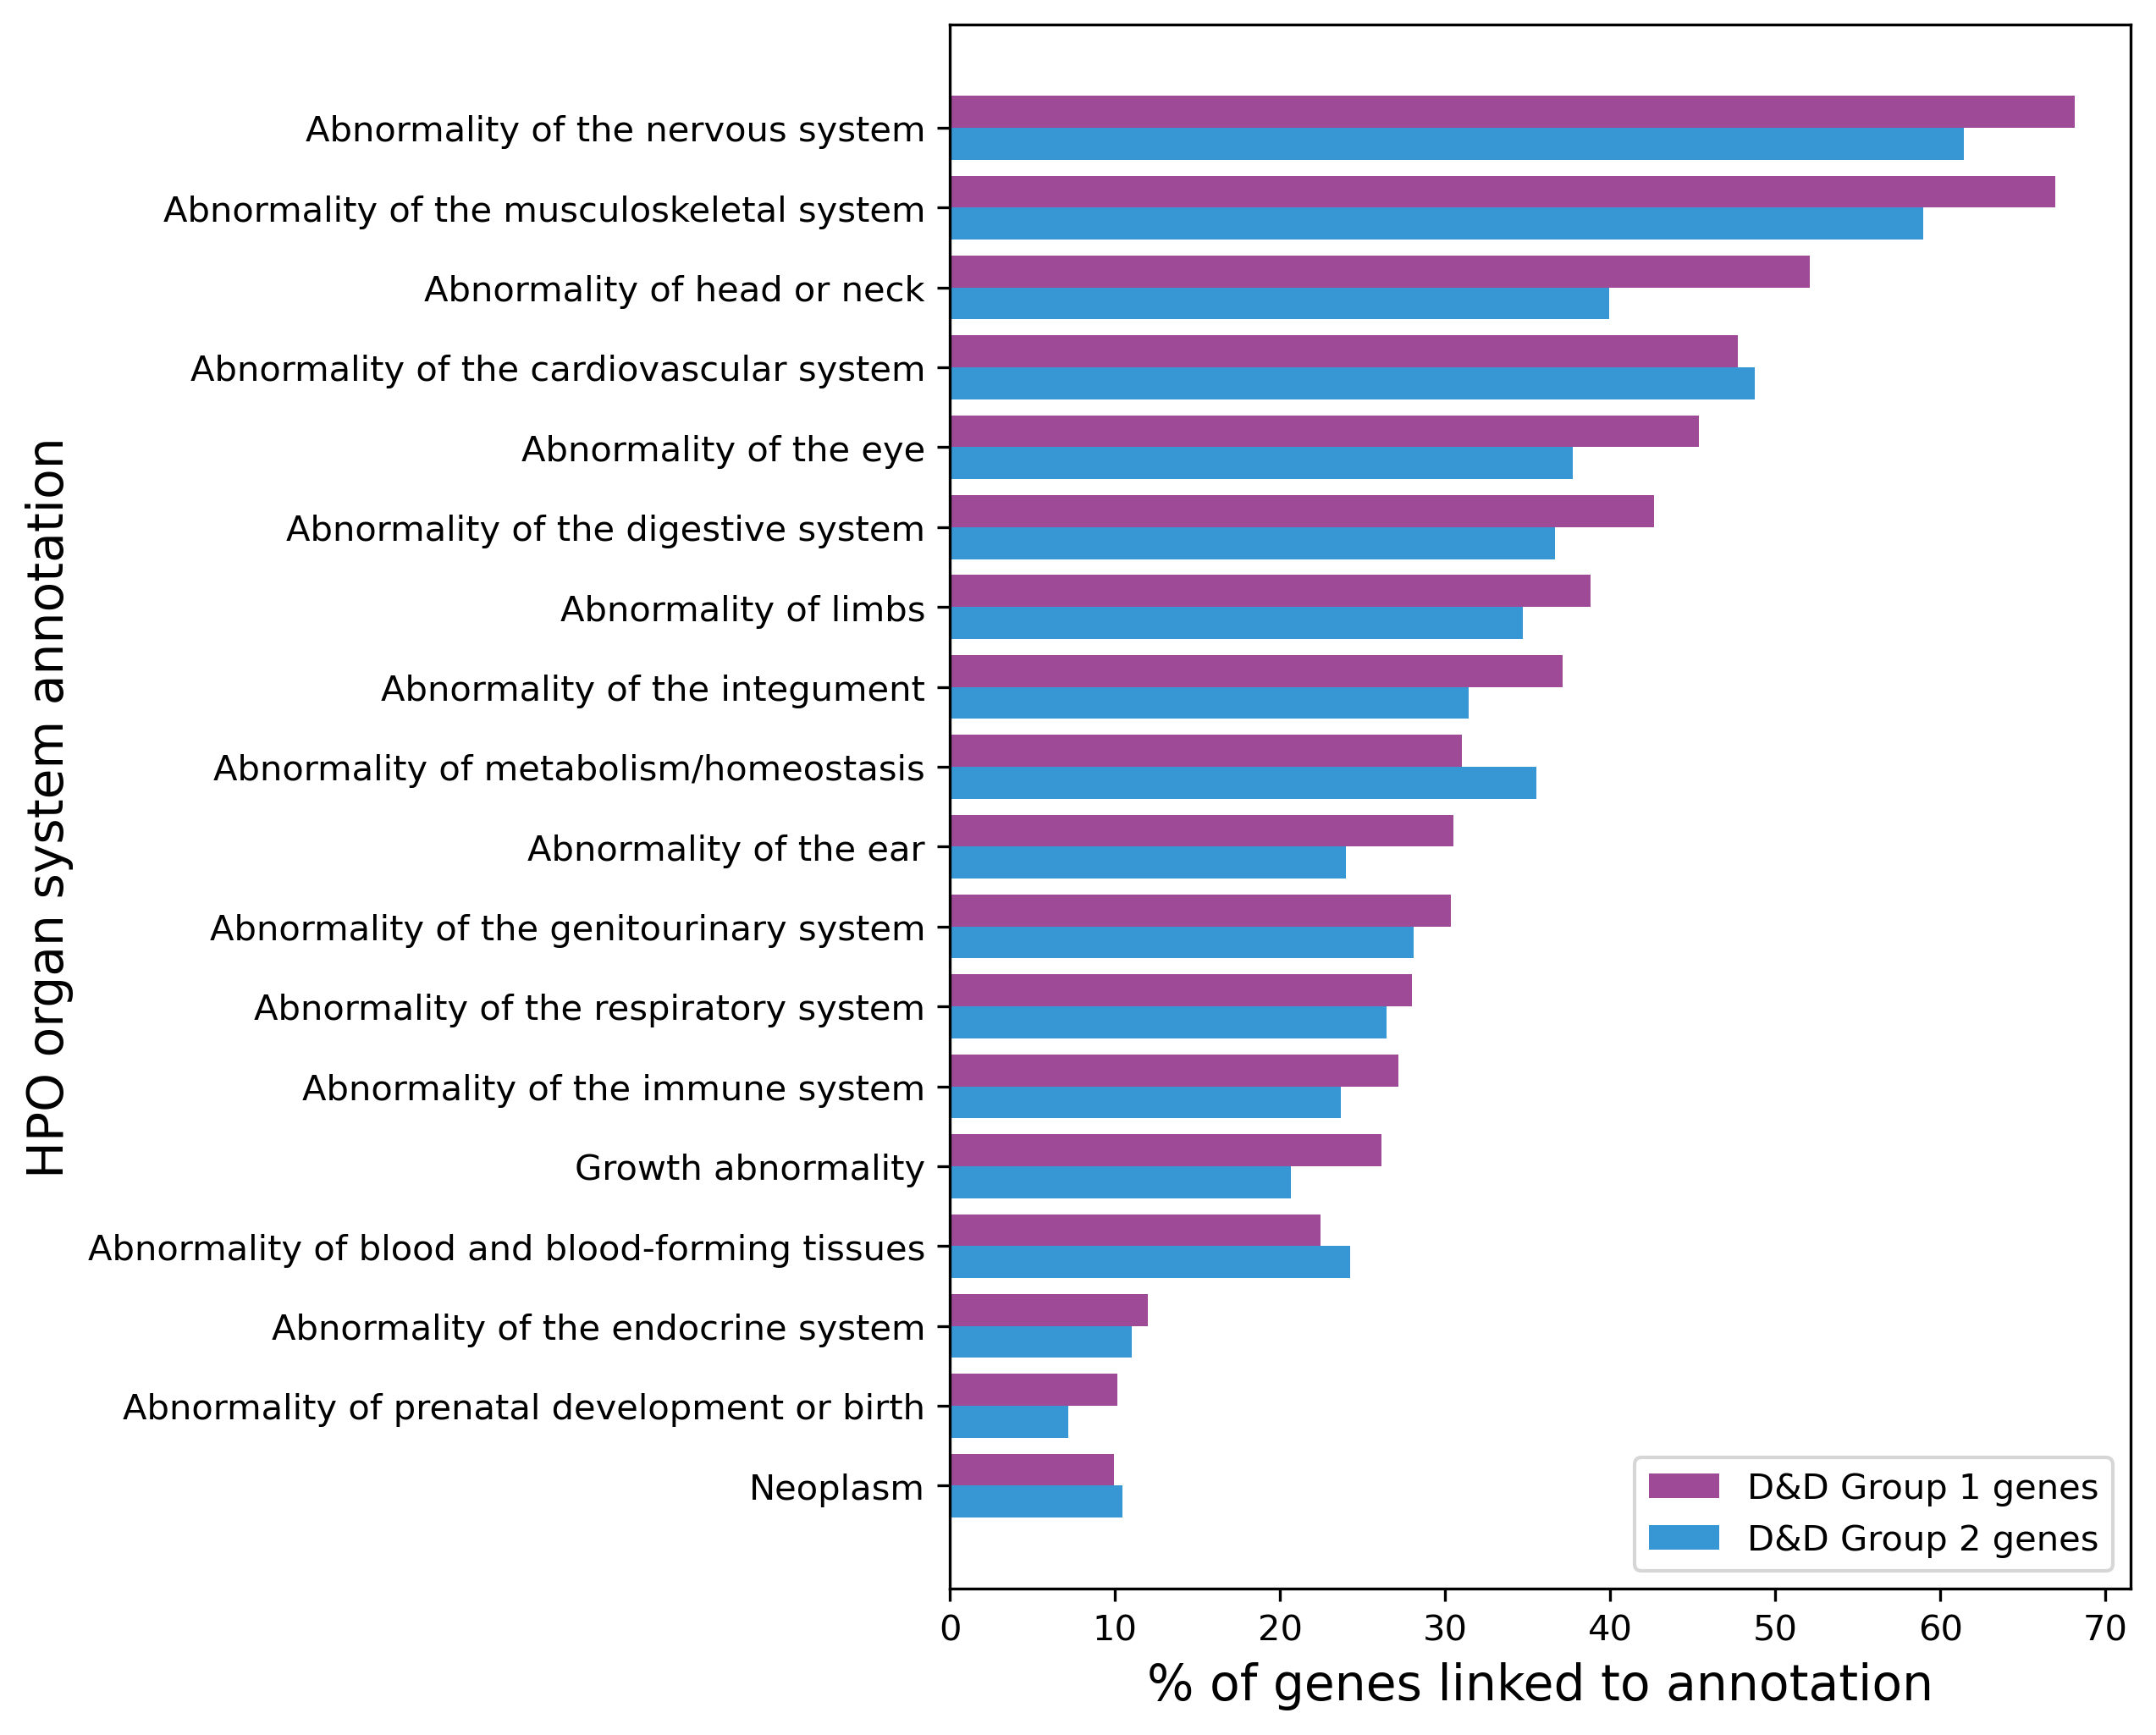

In [299]:
# first, plot just the dHS genes
num_genes_group1=len(list(set(gene2_top_level.keys())))
print(num_genes_group1)
num_genes_group2=len(g2_genes)
print(num_genes_group2)
plt.figure(figsize=(6, 8))

# remove a few categories from the visualization to make less clutered
temp_plot_df=term_df[~term_df['term'].isin(['Constitutional symptom','Abnormal cellular phenotype','Abnormality of the breast','Abnormality of the voice','Abnormality of the thoracic cavity'])]
temp_plot_df.reset_index(inplace=True, drop=True)

# numeric y positions
y = np.arange(len(temp_plot_df))
bar_height = 0.4

plt.barh(
    y + bar_height/2,
    (temp_plot_df['num_genes_w_term_g1'] / num_genes_group1) * 100,
    height=bar_height,
    color='#9f4a96',
    label='D&D Group 1 genes'
)

plt.barh(
    y - bar_height/2,
    (temp_plot_df['num_genes_w_term_g2'] / num_genes_group2) * 100,
    height=bar_height,
    color='#3697d4',
    label='D&D Group 2 genes'
)

plt.yticks(y, temp_plot_df['term'],fontsize=10)
plt.xlabel('% of genes linked to annotation', fontsize=14)
plt.ylabel('HPO organ system annotation',fontsize=14)
plt.legend()
savedir="/Users/graceramey/Library/CloudStorage/Box-Box/capra_lab/projects/dominant_negative_disease_editing/figures/jupyter_notebook_savefigs"
plt.savefig(savedir + "/HPO_terms_dominant.svg", format='svg', bbox_inches='tight',transparent=True)
plt.show()

# Below we'll run a permutation test to see if any category is over or underrepresented

Load all HPO genes as the background set to select from.

In [307]:
# load all genes with phenotype mappings in HPO
g2p_file="../../data/hpo/genes_to_phenotype.txt"
g2p=pd.read_table(g2p_file)
g2p

,ncbi_gene_id,gene_symbol,hpo_id,hpo_name,frequency,disease_id
0,10,NAT2,HP:0000007,Autosomal recessive inheritance,-,OMIM:243400
1,10,NAT2,HP:0001939,Abnormality of metabolism/homeostasis,-,OMIM:243400
2,16,AARS1,HP:0002460,Distal muscle weakness,15/15,OMIM:613287
3,16,AARS1,HP:0002451,Limb dystonia,3/3,OMIM:616339
4,16,AARS1,HP:0008619,Bilateral sensorineural hearing impairment,HP:0040283,ORPHA:33364
...,...,...,...,...,...,...
322510,136932118,-,HP:0005987,Multinodular goiter,3/13,OMIM:609893
322511,136932118,-,HP:0003593,Infantile onset,8/13,OMIM:609893
322512,136932118,-,HP:0003581,Adult onset,5/13,OMIM:609893
322513,136932118,-,HP:0000821,Hypothyroidism,13/13,OMIM:609893


In [308]:
# now, get the HPO terms for each of the genes across the sets

# filter the g2p data to only include terms of certain frequency levels - we're using 80% or higher
keep=[]
frequency_filters_str=['HP:0040281', 'HP:0040280', '-']
frequency_filter_float=0.8
for item in g2p.frequency:
    if isinstance(item, str):
        keep.append(1 if item in frequency_filters_str else 0)

    elif isinstance(item, (float, int)):
        keep.append(1 if item >= frequency_filter_float else 0)

    else:
        keep.append(0)
g2p['keep']=keep
g2p_ff = g2p[g2p['keep']==1]
g2p_ff

,ncbi_gene_id,gene_symbol,hpo_id,hpo_name,frequency,disease_id,keep
0,10,NAT2,HP:0000007,Autosomal recessive inheritance,-,OMIM:243400,1
1,10,NAT2,HP:0001939,Abnormality of metabolism/homeostasis,-,OMIM:243400,1
12,16,AARS1,HP:0001298,Encephalopathy,HP:0040281,ORPHA:442835,1
24,16,AARS1,HP:0001284,Areflexia,-,OMIM:613287,1
55,16,AARS1,HP:0000007,Autosomal recessive inheritance,-,OMIM:619691,1
...,...,...,...,...,...,...,...
322498,111365204,-,HP:0000533,Chorioretinal atrophy,-,OMIM:600790,1
322499,111365204,-,HP:0000545,Myopia,-,OMIM:600790,1
322500,120766137,HRURF,HP:0000006,Autosomal dominant inheritance,-,OMIM:146550,1
322504,120766137,HRURF,HP:0000653,Sparse eyelashes,-,OMIM:146550,1


In [309]:
# get all unique genes from that
g2p_ff=g2p_ff[~g2p_ff['gene_symbol'].isna()]
g2p_ff=g2p_ff[g2p_ff['gene_symbol']!='-']
all_genes=list(set(g2p_ff['gene_symbol']))
print(len(all_genes))

5164


In [310]:
# select 100 random sets of 200 genes at a time from the set
n_perm=100
n_set=200
gene_sets=set()
rng = np.random.default_rng(120)

for i in range(n_perm):
    cur_sample=rng.choice(all_genes, size=n_set, replace=False)
    gene_sets.add(frozenset(cur_sample))
print(len(gene_sets))

100


In [332]:
# flatten all genes into one set
all_perm_genes = set().union(*gene_sets)

# filter the hpo df to just these genes
g2p_fff = g2p_ff[g2p_ff['gene_symbol'].isin(all_perm_genes)]

# get unique hpo terms from the filtered data
all_perm_genes_hpos = set(g2p_fff['hpo_id'])
print(len(all_perm_genes_hpos))

# change get_top_level_terms a bit to only return the name of the HPO term, not the id as well
def get_top_level_categories(hpo_id):
    """Return top-level HPO categories (direct children of HP:0000118)
    that are ancestors of the given HPO term."""
    if hpo_id not in graph:
        return []
    ancestors = nx.ancestors(graph.reverse(), hpo_id)
    # keep only ancestors that are direct children of ROOT_ID
    matches = [tid for tid in top_level_ids if tid in ancestors]
    return [(top_level_terms[tid]) for tid in matches]

from functools import lru_cache

# ---------------------------
# 1️⃣ Reverse the graph once (don't do it in every call)
# ---------------------------
reversed_graph = graph.reverse(copy=False)
top_level_ids_set = set(top_level_ids)

# ---------------------------
# 2️⃣ Cache the results of top-level lookup
# ---------------------------
@lru_cache(maxsize=None)
def get_top_level_categories_cached(hpo_id):
    """Return only the top-level HPO names for a given HPO ID."""
    if hpo_id not in reversed_graph:
        return []
    ancestors = nx.ancestors(reversed_graph, hpo_id)
    # intersect with your top_level_ids
    matches = top_level_ids_set.intersection(ancestors)
    # return the names
    return [top_level_terms[tid] for tid in matches]

# ---------------------------
# 3️⃣ Build the mapping efficiently
# ---------------------------
hpo2_tl = {}
for i, hpo in enumerate(all_perm_genes_hpos):
    hpo2_tl[hpo] = get_top_level_categories_cached(hpo)
    if i % 1000 == 0:
        print(f"Processed {i} / {len(all_perm_genes_hpos)} HPO terms")


6862
Processed 0 / 6862 HPO terms
Processed 1000 / 6862 HPO terms
Processed 2000 / 6862 HPO terms
Processed 3000 / 6862 HPO terms
Processed 4000 / 6862 HPO terms
Processed 5000 / 6862 HPO terms
Processed 6000 / 6862 HPO terms


In [334]:
hpo2_tl # view the top level terms for the background genes

{'HP:0012217': ['Abnormality of metabolism/homeostasis',
  'Abnormality of the genitourinary system'],
 'HP:0003375': ['Abnormality of the musculoskeletal system'],
 'HP:0000176': ['Abnormality of head or neck'],
 'HP:0410145': ['Abnormality of metabolism/homeostasis'],
 'HP:0031206': ['Abnormality of the nervous system'],
 'HP:0010168': ['Abnormality of limbs',
  'Abnormality of the musculoskeletal system'],
 'HP:0000618': ['Abnormality of the eye'],
 'HP:0005511': ['Abnormality of blood and blood-forming tissues'],
 'HP:0000327': ['Abnormality of head or neck',
  'Abnormality of the musculoskeletal system'],
 'HP:0001895': ['Abnormality of blood and blood-forming tissues'],
 'HP:0006268': ['Abnormality of the digestive system',
  'Abnormality of the immune system',
  'Abnormality of the cardiovascular system'],
 'HP:0002524': ['Abnormality of the nervous system'],
 'HP:0008366': ['Abnormality of limbs',
  'Abnormality of the musculoskeletal system'],
 'HP:0004611': ['Abnormality of t

In [341]:
g2p_fff # view the filtered data

,ncbi_gene_id,gene_symbol,hpo_id,hpo_name,frequency,disease_id,keep
0,10,NAT2,HP:0000007,Autosomal recessive inheritance,-,OMIM:243400,1
1,10,NAT2,HP:0001939,Abnormality of metabolism/homeostasis,-,OMIM:243400,1
12,16,AARS1,HP:0001298,Encephalopathy,HP:0040281,ORPHA:442835,1
24,16,AARS1,HP:0001284,Areflexia,-,OMIM:613287,1
55,16,AARS1,HP:0000007,Autosomal recessive inheritance,-,OMIM:619691,1
...,...,...,...,...,...,...,...
322388,101929726,MYMX,HP:0000463,Anteverted nares,HP:0040281,ORPHA:1358,1
322395,101929726,MYMX,HP:0000508,Ptosis,HP:0040281,ORPHA:1358,1
322462,105371045,PERCC1,HP:0000007,Autosomal recessive inheritance,-,OMIM:618662,1
322500,120766137,HRURF,HP:0000006,Autosomal dominant inheritance,-,OMIM:146550,1


In [28]:
## We could also potentially use the dominant HPO terms to map to OMIM disease IDs as an alternative, but for now we'll stick with this approach

In [342]:
# Now we have each HPO term and its top level labels

# create gene to lower hpo_id mapping
gene2hpo_perm = g2p_fff.groupby('gene_symbol')['hpo_id'].apply(set).to_dict()

# map permuted genes to top level terms
gene2top_level_perm = {
    gene: {tl for hpo in hpos for tl in hpo2_tl.get(hpo, [])}
    for gene, hpos in gene2hpo_perm.items()
}

In [344]:
print(len(gene2top_level_perm))
gene2top_level_perm # view the top level terms for the permuted gene sets

5048


{'A2ML1': {'Abnormality of the ear', 'Abnormality of the immune system'},
 'A4GALT': {'Abnormality of blood and blood-forming tissues'},
 'AAAS': {'Abnormality of head or neck',
  'Abnormality of limbs',
  'Abnormality of the cardiovascular system',
  'Abnormality of the digestive system',
  'Abnormality of the endocrine system',
  'Abnormality of the eye',
  'Abnormality of the integument',
  'Abnormality of the musculoskeletal system',
  'Abnormality of the nervous system',
  'Growth abnormality'},
 'AAGAB': {'Abnormality of limbs', 'Abnormality of the integument'},
 'AARS1': {'Abnormality of limbs',
  'Abnormality of the ear',
  'Abnormality of the musculoskeletal system',
  'Abnormality of the nervous system'},
 'AARS2': {'Abnormality of the nervous system'},
 'AASS': {'Abnormality of blood and blood-forming tissues',
  'Abnormality of metabolism/homeostasis',
  'Abnormality of the eye',
  'Abnormality of the musculoskeletal system',
  'Abnormality of the nervous system'},
 'ABAT':

In [354]:
# Now split these back up for each permutation set

# new set to store each perm as a dict of term counts
perm_term_counts = []

# create a set of all top-level term names
all_top_level_terms = set(top_level_terms.values())

for perm in gene_sets:
    # initialize counts dictionary for this permutation
    term_counts = {term: 0 for term in all_top_level_terms}
    
    # increment counts based on genes in this perm
    for gene in perm:
        # get the gene's top-level terms
        cur_terms = gene2top_level_perm.get(gene, set())
        for term in cur_terms:
            term_counts[term] += 1
    
    # add this perm's dict to the list
    perm_term_counts.append(term_counts)

perm_dfs = []
for term_counts in perm_term_counts:
    df = pd.DataFrame({
        'term': list(term_counts.keys()),
        'num_genes_w_term': list(term_counts.values()),
        'percentage_total_genes':[(x/200)*100 for x in list(term_counts.values())]
    })
    perm_dfs.append(df)

In [355]:
perm_dfs[0] # look at the counts for one out of the 100 permutations

,term,num_genes_w_term,percentage_total_genes
0,Abnormality of the genitourinary system,47,23.5
1,Abnormality of prenatal development or birth,9,4.5
2,Abnormality of the endocrine system,26,13.0
3,Abnormality of the integument,55,27.5
4,Abnormal cellular phenotype,19,9.5
5,Abnormality of the thoracic cavity,1,0.5
6,Abnormality of the nervous system,118,59.0
7,Abnormality of metabolism/homeostasis,67,33.5
8,Abnormality of the ear,46,23.0
9,Abnormality of the digestive system,56,28.0


In [356]:
# now we want to store the distributions of percentages for each top level term
percentage_dict={}
for term in list(top_level_terms.values()):
    cur_term_distribution=[]
    for perm_df in perm_dfs:
        # filter to the current term
        cur_term_percentage = (perm_df[perm_df['term']==term])['percentage_total_genes'].values[0]
        # add to the term's distribution
        cur_term_distribution.append(cur_term_percentage)
    percentage_dict[term]=cur_term_distribution
percentage_dict # view the percentages across each perm for every organ system

{'Abnormality of the genitourinary system': [23.5,
  23.0,
  21.5,
  25.5,
  23.0,
  27.0,
  31.5,
  29.5,
  27.0,
  24.5,
  25.0,
  30.0,
  25.0,
  25.5,
  23.0,
  29.5,
  24.0,
  21.0,
  31.0,
  26.5,
  21.5,
  19.5,
  26.0,
  27.0,
  30.5,
  25.0,
  22.0,
  24.0,
  23.5,
  22.5,
  25.5,
  28.000000000000004,
  22.0,
  23.0,
  24.5,
  28.000000000000004,
  27.500000000000004,
  22.0,
  24.5,
  28.999999999999996,
  27.500000000000004,
  22.0,
  24.5,
  24.0,
  24.0,
  28.000000000000004,
  27.500000000000004,
  24.0,
  21.5,
  30.0,
  27.0,
  27.0,
  31.0,
  26.0,
  24.5,
  26.5,
  29.5,
  25.0,
  26.0,
  25.0,
  23.0,
  25.0,
  25.5,
  23.5,
  25.5,
  23.0,
  30.5,
  30.5,
  22.0,
  25.5,
  20.0,
  24.5,
  25.5,
  21.0,
  26.5,
  24.0,
  26.5,
  30.5,
  29.5,
  20.0,
  32.5,
  30.0,
  30.5,
  23.0,
  19.5,
  26.0,
  27.500000000000004,
  23.0,
  24.5,
  21.0,
  28.499999999999996,
  23.0,
  22.0,
  27.0,
  25.5,
  27.500000000000004,
  24.0,
  24.5,
  27.500000000000004,
  28.499999

In [359]:
# Now let's compare to our observed values
term_df['percentage_total_g1_genes']=100*term_df['num_genes_w_term_g1']/593 # number of dnd group 1 genes
term_df['percentage_total_g2_genes']=100*term_df['num_genes_w_term_g2']/363 # number of dnd group 2 genes
term_df

,term,num_genes_w_term_g1,num_genes_w_term_g2,percentage_total_g1_genes,percentage_total_g2_genes
0,Abnormality of the thoracic cavity,2,1,0.337268,0.275482
1,Abnormality of the breast,24,6,4.047218,1.652893
2,Abnormality of the voice,25,13,4.215852,3.581267
3,Abnormal cellular phenotype,46,25,7.757167,6.887052
4,Neoplasm,59,38,9.949410,10.468320
5,Abnormality of prenatal development or birth,60,26,10.118044,7.162534
6,Abnormality of the endocrine system,71,40,11.973019,11.019284
7,Constitutional symptom,89,66,15.008432,18.181818
8,Abnormality of blood and blood-forming tissues,133,88,22.428331,24.242424
9,Growth abnormality,155,75,26.138280,20.661157


## We actually want to see if there is any difference, higher or lower, than the percentages under the null distribution.

So for this, we'll compute the difference between the observed proportion and the permutation proportion for each of the 100 permutations.

In [362]:
from statsmodels.stats.multitest import multipletests
# see how many permutated stats were as or more extreme than our observed percentage stat
plot_df=term_df.copy()
plot_df.rename(columns={'percentage_total_g1_genes':'G1_percentage', 'percentage_total_g2_genes':'G2_percentage'},inplace=True)
pval_G1_dict={}
pval_G2_dict={}
effect_G1_dict={}
effect_G2_dict={}
for term in list(percentage_dict.keys()):
    null_distribution=list(percentage_dict[term])
    obs_test_stat_G1 = plot_df[plot_df.term==term]['G1_percentage'].values[0]
    obs_test_stat_G2 = plot_df[plot_df.term==term]['G2_percentage'].values[0]

    # compute observed deviation from the mean of the null distribution
    null_mean=np.mean(null_distribution)
    G1_obs_deviation=abs(obs_test_stat_G1-null_mean)
    G2_obs_deviation=abs(obs_test_stat_G2-null_mean)

    # get number of extreme values and pval
    extreme_values_count_G1 = np.sum(abs(null_distribution - null_mean) >= G1_obs_deviation)
    p_value_G1 = extreme_values_count_G1 / len(null_distribution)

    extreme_values_count_G2 = np.sum(abs(null_distribution - null_mean) >= G2_obs_deviation)
    p_value_G2 = extreme_values_count_G2 / len(null_distribution)

    # store pvals & do bonferroni
    pval_G1_dict[term] = p_value_G1 #* 23
    pval_G2_dict[term] = p_value_G2 #* 23

    # get effect sizes with sign
    effect_G1 = (obs_test_stat_G1 - null_mean)
    effect_G2 = (obs_test_stat_G2 - null_mean)
    effect_G1_dict[term] = effect_G1
    effect_G2_dict[term] = effect_G2


# get fdr corrected pvals
terms = list(pval_G1_dict.keys())

# build p-value arrays
pvals_G1 = np.array([pval_G1_dict[t] for t in terms])
pvals_G2 = np.array([pval_G2_dict[t] for t in terms])

# BH correction (separate per group)
_, qvals_G1, _, _ = multipletests(pvals_G1, method="fdr_bh")
_, qvals_G2, _, _ = multipletests(pvals_G2, method="fdr_bh")

# store back into dictionaries
qval_G1_dict = dict(zip(terms, qvals_G1))
qval_G2_dict = dict(zip(terms, qvals_G2))


## Print out each percentage difference and the significance

In [363]:
print('D&D Group 1 term enrichments pre p adjustment')
for term in list(percentage_dict.keys()):
    if qval_G1_dict[term]<=0.05:
        print(term)
        print(f"effect size (% difference): {effect_G1_dict[term]:.2f}")
        print(f"p val: {pval_G1_dict[term]:.2f}")
        print(f"q val(FDR corrected p val): {qval_G1_dict[term]:.2f}")
        print("---------------------")


D&D Group 1 term enrichments pre p adjustment
Abnormality of head or neck
effect size (% difference): 16.42
p val: 0.00
q val(FDR corrected p val): 0.00
---------------------
Abnormality of the eye
effect size (% difference): 14.40
p val: 0.00
q val(FDR corrected p val): 0.00
---------------------
Abnormality of the ear
effect size (% difference): 11.42
p val: 0.00
q val(FDR corrected p val): 0.00
---------------------
Abnormality of the nervous system
effect size (% difference): 15.90
p val: 0.00
q val(FDR corrected p val): 0.00
---------------------
Abnormality of prenatal development or birth
effect size (% difference): 4.93
p val: 0.00
q val(FDR corrected p val): 0.00
---------------------
Abnormality of the integument
effect size (% difference): 10.80
p val: 0.00
q val(FDR corrected p val): 0.00
---------------------
Abnormality of the cardiovascular system
effect size (% difference): 22.90
p val: 0.00
q val(FDR corrected p val): 0.00
---------------------
Abnormality of blood and

## Do the same for group 2 genes

In [366]:
print('D&D Group 2 term enrichments pre p adjustment')
for term in list(percentage_dict.keys()):
    if qval_G2_dict[term]<=0.05:
        print(term)
        print(f"effect size (% difference): {effect_G2_dict[term]:.2f}")
        print(f"p val: {pval_G2_dict[term]:.2f}")
        print(f"q val(FDR corrected p val): {qval_G2_dict[term]:.2f}")
        print("---------------------")


D&D Group 2 term enrichments pre p adjustment
Abnormality of the nervous system
effect size (% difference): 9.20
p val: 0.01
q val(FDR corrected p val): 0.03
---------------------
Abnormality of the cardiovascular system
effect size (% difference): 23.94
p val: 0.00
q val(FDR corrected p val): 0.00
---------------------
Abnormality of blood and blood-forming tissues
effect size (% difference): 10.76
p val: 0.00
q val(FDR corrected p val): 0.00
---------------------
Abnormality of the respiratory system
effect size (% difference): 10.38
p val: 0.00
q val(FDR corrected p val): 0.00
---------------------
Abnormality of the digestive system
effect size (% difference): 9.49
p val: 0.00
q val(FDR corrected p val): 0.00
---------------------
Constitutional symptom
effect size (% difference): 8.54
p val: 0.00
q val(FDR corrected p val): 0.00
---------------------
Abnormality of the musculoskeletal system
effect size (% difference): 12.69
p val: 0.00
q val(FDR corrected p val): 0.00
-----------

In [367]:
# store in a data frame

rows = []

for term in terms:
    rows.append({
        "term": term,

        "G1_effect": effect_G1_dict.get(term),
        "G1_pval":   pval_G1_dict.get(term),
        "G1_qval":   qval_G1_dict.get(term),

        "G2_effect": effect_G2_dict.get(term),
        "G2_pval":   pval_G2_dict.get(term),
        "G2_qval":   qval_G2_dict.get(term),
    })

results_df = pd.DataFrame(rows)
results_df



,term,G1_effect,G1_pval,G1_qval,G2_effect,G2_pval,G2_qval
0,Abnormality of the genitourinary system,4.854132,0.13,0.199333,2.599174,0.36,0.460000
1,Abnormality of head or neck,16.422926,0.00,0.000000,4.259904,0.25,0.338235
2,Abnormality of the eye,14.402563,0.00,0.000000,6.781047,0.04,0.092000
3,Abnormality of the ear,11.422766,0.00,0.000000,4.866942,0.11,0.194615
4,Abnormality of the nervous system,15.898162,0.00,0.000000,9.202507,0.01,0.028750
5,Abnormality of the breast,0.882218,0.41,0.523889,-1.512107,0.21,0.301875
6,Abnormality of the endocrine system,0.603019,0.83,0.909048,-0.350716,0.93,0.972273
7,Abnormality of prenatal development or birth,4.928044,0.00,0.000000,1.972534,0.21,0.301875
8,Growth abnormality,-0.301720,0.96,1.000000,-5.778843,0.05,0.095833
9,Abnormality of the integument,10.799494,0.00,0.000000,5.104959,0.12,0.197143


In [370]:
results_df.sort_values(by=['G1_qval'], ascending=True)

,term,G1_effect,G1_pval,G1_qval,G2_effect,G2_pval,G2_qval
11,Abnormality of the cardiovascular system,22.898440,0.00,0.000000,23.935331,0.00,0.000000
1,Abnormality of head or neck,16.422926,0.00,0.000000,4.259904,0.25,0.338235
2,Abnormality of the eye,14.402563,0.00,0.000000,6.781047,0.04,0.092000
3,Abnormality of the ear,11.422766,0.00,0.000000,4.866942,0.11,0.194615
4,Abnormality of the nervous system,15.898162,0.00,0.000000,9.202507,0.01,0.028750
20,Abnormality of the musculoskeletal system,20.687723,0.00,0.000000,12.693168,0.00,0.000000
18,Constitutional symptom,5.368432,0.00,0.000000,8.541818,0.00,0.000000
7,Abnormality of prenatal development or birth,4.928044,0.00,0.000000,1.972534,0.21,0.301875
17,Abnormality of the digestive system,15.514418,0.00,0.000000,9.489118,0.00,0.000000
9,Abnormality of the integument,10.799494,0.00,0.000000,5.104959,0.12,0.197143
